# Exercise: Deep Learning and the Curse of Dimensionality 

This brief notebook will illustrate how to implement *Convolutional Neural Networks* in *Pytorch*, and demonstrate why they are far more suitable than *Feed-forward Neural Networks* for dealing with image datasets and computer vision problems.

We will initially use the <a href="http://yann.lecun.com/exdb/mnist/">*MNIST*</a> digit dataset and then move to the <a href="https://www.cs.toronto.edu/~kriz/cifar.html">*CIFAR10*</a> dataset. The CIFAR-10 dataset consists of 60000 32x32 colour images in 10 classes, with 6000 images per class. There are 50000 training images and 10000 test images. This more complex dataset, although simple for current standards, will better show the superiority of *CNN* over *FNN*.

<br>

<p alt="CIFAR10" align="center">
<img src="https://miro.medium.com/v2/resize:fit:495/0*94t_5cPF9mvBj20z.png" width="400"/>
<img src="https://miro.medium.com/max/944/1*6XQqOifwnmplS22zCRRVaw.png" width="512"/>
</p>

<br>

The rest of the notebook is organized as follows:

1. CNN vs FNN on MNIST
2. CNN vs FNN on CIFAR10
3. Improving generalization performances with bigger models


First, let us load the libraries we need.

In [1]:
# pytorch
import torch
import torch.nn as nn
from torch.nn import Linear, Conv2d, ReLU
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
torch.manual_seed(42) #set the seed to have a repeatable training process

# others
import numpy as np
import matplotlib.pyplot as plt
import random
from cycler import cycler
import seaborn as sns

# Set the color scheme
sns.set_theme()
colors = ['#0076C2', '#EC6842', '#A50034', '#009B77', '#FFB81C', '#E03C31', '#6CC24A', '#EF60A3', '#0C2340', '#00B8C8', '#6F1D77']
plt.rcParams['axes.prop_cycle'] = cycler(color=colors)
plt.rcParams.update({'font.size': 12})

# This line is used to select GPU to train, if available
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

# 1. CNN vs ANN on MNIST

## Load dataset and explore samples

We'll start by loading the training and testing dataset from MNIST.
This is a dataset of hand-written numbers from 0 to 9.

In [2]:
# load the MNIST dataset
root = '../../../../datasets/mnist'

train_set = datasets.MNIST(root=root, download=True, train=True, transform=transforms.ToTensor())
test_set = datasets.MNIST(root=root, download=True, train=False, transform=transforms.ToTensor())

# get number of classes
num_classes = len(train_set.classes)
print(f'number of classes: {num_classes}')

# print information on the dataset
print('\nTraining dataset:')
print(f'input.shape: {train_set.data.shape}')
print(f'target.shape: {train_set.targets.shape}')

print('\nTesting dataset:')
print(f'input.shape: {test_set.data.shape}')
print(f'target.shape: {test_set.targets.shape}')

number of classes: 10

Training dataset:
input.shape: torch.Size([60000, 28, 28])
target.shape: torch.Size([60000])

Testing dataset:
input.shape: torch.Size([10000, 28, 28])
target.shape: torch.Size([10000])


### Visualize a random image 

to have a feeling of what it looks like. You can repeat running this cell as you wish to see further examples...

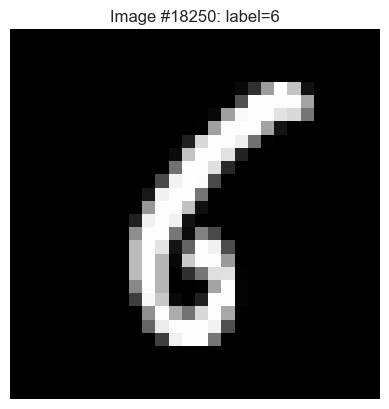

In [3]:
# select random image
ix = random.randint(0, train_set.data.shape[0])
img = train_set.data[ix,:,:].cpu()

# plot image
plt.imshow(img, cmap='gray')
plt.title(f'Image #{ix}: label={train_set.targets[ix]}')
plt.axis('off');

## Define Feed-forward Neural Network (FNN) model

To begin, we'll start simple by defining and training a feed-forward neural network, which you have already seen in previous lectures.

### Model definition

We create a FNN as a subclass of torch.nn.Module by defining three layers in the constructor and adding activation functions in the forward pass.

In [4]:
class FNN(nn.Module):
    def __init__(self, input_size, num_classes, hidden_features=64):
        super().__init__()
        self.lin1 = Linear(input_size, hidden_features)
        self.lin2 = Linear(hidden_features, hidden_features)
        self.lin3 = Linear(hidden_features, num_classes)

    def forward(self, x):
        x = x.reshape(x.shape[0], -1) # reshape input to fit the FNN

        x = self.lin1(x)
        x = nn.ReLU()(x)
        x = self.lin2(x)
        x = nn.ReLU()(x)
        x = self.lin3(x)
        
        x = F.log_softmax(x, dim=1)
        
        return x

### Model instantiation

Let's create an instance of the FNN class we just defined.

As you can see, since the MNIST images are of size 28x28 = 784, the number of parameters in the FNN increases very rapidly.

In [5]:
input_size = train_set.data[0].reshape(-1).shape[0]

model = FNN(input_size, num_classes, hidden_features=256)

print("Total number of paramters:", sum(p.numel() for p in model.parameters()))
print(model)

Total number of paramters: 269322
FNN(
  (lin1): Linear(in_features=784, out_features=256, bias=True)
  (lin2): Linear(in_features=256, out_features=256, bias=True)
  (lin3): Linear(in_features=256, out_features=10, bias=True)
)


### Define training and evaluation functions
We create some general functions for training and testing, so that we can repeat them later on.

In [6]:
def train_epoch(model, loader, optimizer, loss_function, device='cpu'):
  # Add only return and the student explains what it does
    model.to(device)
    model.train() # specifies that the model is in training mode
    losses = []
    correct_preds = 0

    for batch in loader:
        # extract inputs x and output target from batch
        inputs, target = batch
        inputs = inputs.to(device)
        target = target.to(device)

        # Model prediction
        preds = model(inputs) 
        
        # MSE loss function
        loss = loss_function(preds, target)

        # Save accuracy
        correct_preds += torch.sum(preds.max(1)[1] == target)
        
        losses.append(loss.cpu().detach())
        
        # Backpropagate and update weights
        loss.backward()   # compute the gradients using backpropagation
        optimizer.step()  # update the weights with the optimizer
        optimizer.zero_grad(set_to_none=True)   # reset the computed gradients      

    accuracy = correct_preds/len(loader.dataset)*100

    return np.array(losses).mean(), accuracy.item()

In [7]:
def evaluation(model, loader, loss_function, device='cpu'):
    model.to(device)
    model.eval() # specifies that the model is in evaluation mode
    losses = []
    correct_preds = 0
    
    # Remove gradients computations since we are only evaluating and not training
    with torch.no_grad():
        for batch in loader:
            # extract inputs x and outputs y from batch
            inputs, target = batch
            inputs = inputs.to(device)
            target = target.to(device)

            # Model prediction
            preds = model(inputs)

            # MSE loss function
            loss = loss_function(preds, target)
            losses.append(loss.cpu())
            
            # Save accuracy
            correct_preds += torch.sum(preds.max(1)[1] == target)

    accuracy = correct_preds/len(loader.dataset)*100

    return np.array(losses).mean(), accuracy.item()

In [8]:
# Set training parameters
learning_rate = 0.001
batch_size = 128
num_epochs = 10

# Create the training and validation dataloaders to "feed" data to the model in batches
train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False)

# Create the optimizer to train the neural network via back-propagation
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)

# Create loss function
loss_function = nn.CrossEntropyLoss()

In [9]:
#create vector for saving losses and accuracies during training
FNN_history = {
    'train_losses' : [],
    'test_losses' : [],
    'train_accuracies' : [],
    'test_accuracies' : [],
}

for epoch in range(1, num_epochs+1):
    # Model training
    train_loss, train_accuracy = train_epoch(model, train_loader, optimizer, loss_function, device=device)
    test_loss, test_accuracy = evaluation(model, test_loader, loss_function, device=device)

    FNN_history['train_losses'].append(train_loss)
    FNN_history['train_accuracies'].append(train_accuracy)
    
    FNN_history['test_losses'].append(test_loss)
    FNN_history['test_accuracies'].append(test_accuracy)

    # print loss every epoch
    if epoch%1 == 0:
        print("epoch:",epoch, "\t training accuracy:", np.round(train_accuracy,2), 
                              "\t test accuracy:", np.round(test_accuracy,2))

epoch: 1 	 training accuracy: 90.69 	 test accuracy: 95.66
epoch: 2 	 training accuracy: 96.49 	 test accuracy: 97.05
epoch: 3 	 training accuracy: 97.66 	 test accuracy: 97.36
epoch: 4 	 training accuracy: 98.21 	 test accuracy: 97.79
epoch: 5 	 training accuracy: 98.72 	 test accuracy: 97.82
epoch: 6 	 training accuracy: 98.98 	 test accuracy: 97.95
epoch: 7 	 training accuracy: 99.15 	 test accuracy: 98.05
epoch: 8 	 training accuracy: 99.41 	 test accuracy: 98.09
epoch: 9 	 training accuracy: 99.42 	 test accuracy: 97.61
epoch: 10 	 training accuracy: 99.45 	 test accuracy: 98.01


### Check training loss over the epochs

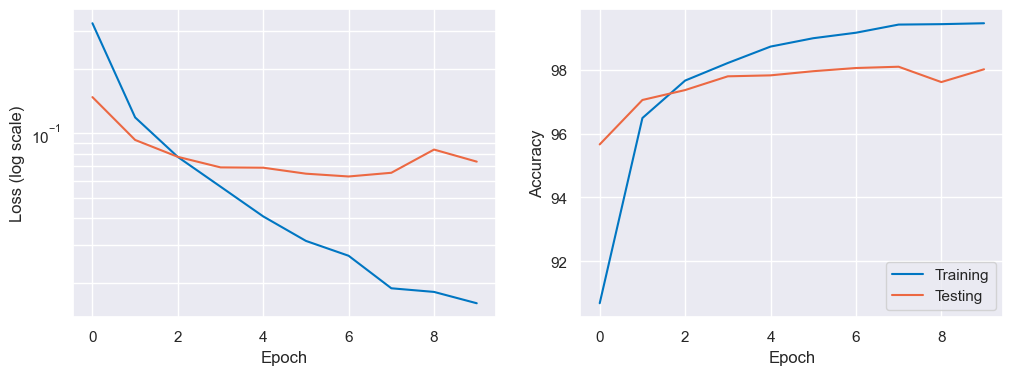

In [10]:
# Create a figure and axis object
fig, axs = plt.subplots(1, 2, figsize=(12,4))

# Plot the training loss and accuracy
axs[0].plot(FNN_history['train_losses'], 'C0-', label='Training')
axs[0].plot(FNN_history['test_losses'], 'C1-', label='Testing')

axs[1].plot(FNN_history['train_accuracies'], 'C0-', label='Training')
axs[1].plot(FNN_history['test_accuracies'], 'C1-', label='Testing')

# Add a legend to the plot
axs[1].legend(loc='lower right')

# Set the plot labels and title
axs[0].set_xlabel('Epoch')
axs[0].set_ylabel('Loss (log scale)')
axs[0].set_yscale('log')

axs[1].set_xlabel('Epoch')
axs[1].set_ylabel('Accuracy')

# Add grid lines to the plot
axs[0].grid(True, which='both')

# Display the plot
plt.show()

The training of the FNN goes smoothly and reaches very good performances both on training and testing.
This is mainly due to the simplicity of the dataset we're considering, which, along with a high number of samples, allows the model to learn to predict the numbers without storing any pattern.

## Convolutional Neural Network (CNN)

Convolutional neural networks, commonly known as CNNs, are models based on convolutional layers.

The convolutional layer is based on the convolution operator.
This consists in sliding a kernel (or filter) matrix, in blue, over an input image and pointwise multiplying the entries of the kernel with the overlapping values in the input image.
The sum of these values corresponds to the respective entry in the output matrix Y.

<p alt="Convolutional kernel" align="center">
<img src="https://upload.wikimedia.org/wikipedia/commons/thumb/1/19/2D_Convolution_Animation.gif/220px-2D_Convolution_Animation.gif" width="300"/>
</p>


We will go further in the details later on but the main advantages of this model are the given by the sharing of this kernel over the whole input.
This both reduces the number of total parameters in the model (since the kernel size is independent from the image size) and introduces a spatial inductive bias, i.e., it makes possible to exploit patterns in the image.


We will train a basic CNN with 2 convolutional layers, followed by an activation function and a pooling layer, connected to a fully-connected layer.

In [11]:
class CNN(nn.Module):
    def __init__(self, num_pixels, input_size, num_classes, hidden_features):
        super().__init__()
        flattened_size = int(hidden_features*2*(num_pixels/4)**2) # we are adding this because of the pooling, which decreases the size of the images
        self.conv1 = Conv2d(in_channels=input_size, out_channels=hidden_features, kernel_size=3, stride=1, padding='same')
        self.pool  = nn.MaxPool2d(2, 2)
        self.conv2 = Conv2d(in_channels=hidden_features, out_channels=hidden_features*2, kernel_size=5, stride=1, padding='same')
        self.final = Linear(flattened_size, num_classes)
        
    def forward(self, x):
        x = self.conv1(x)
        x = ReLU()(x)
        x = self.pool(x)

        x = self.conv2(x)
        x = ReLU()(x)
        x = self.pool(x)

        x = x.view(x.size(0), -1)

        x = self.final(x)
        x = F.log_softmax(x, dim=1)
        
        return x

In [12]:
# The number of input channels is one because we are dealing with gray-scale images.
input_size = 1
num_pixels = 28

# model
model = CNN(num_pixels, input_size, num_classes, hidden_features=8)
print("Total number of paramters:", sum(p.numel() for p in model.parameters()))
print(model)

# Set training parameters
learning_rate = 0.01
batch_size = 32
num_epochs = 10

# Create the training and validation dataloaders to "feed" data to the model in batches
train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False)

# Create the optimizer to train the neural network via back-propagation
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

Total number of paramters: 11146
CNN(
  (conv1): Conv2d(1, 8, kernel_size=(3, 3), stride=(1, 1), padding=same)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(8, 16, kernel_size=(5, 5), stride=(1, 1), padding=same)
  (final): Linear(in_features=784, out_features=10, bias=True)
)


As you can see, the number of parameters is way lower than those of the FNN.
This is because the number of parameters is independent of the images' size.

This features is not only important for the inductive biases it provides but also because it allows us to work with images of any size!

In [13]:
#create vector for saving training loss
CNN_history = {
    'train_losses' : [],
    'test_losses' : [],
    'train_accuracies' : [],
    'test_accuracies' : [],
}

for epoch in range(1, num_epochs+1):
    # Model training
    train_loss, train_accuracy = train_epoch(model, train_loader, optimizer, loss_function, device=device)
    test_loss, test_accuracy = evaluation(model, test_loader, loss_function, device=device)

    CNN_history['train_losses'].append(train_loss)
    CNN_history['train_accuracies'].append(train_accuracy)
    
    CNN_history['test_losses'].append(test_loss)
    CNN_history['test_accuracies'].append(test_accuracy)

    # print loss every epoch
    if epoch%1 == 0:
        print("epoch:",epoch, "\t training accuracy:", np.round(train_accuracy,2), 
                              "\t test accuracy:", np.round(test_accuracy,2))

epoch: 1 	 training accuracy: 96.06 	 test accuracy: 97.46
epoch: 2 	 training accuracy: 97.84 	 test accuracy: 97.92
epoch: 3 	 training accuracy: 98.07 	 test accuracy: 96.76
epoch: 4 	 training accuracy: 98.21 	 test accuracy: 98.08
epoch: 5 	 training accuracy: 98.32 	 test accuracy: 97.74
epoch: 6 	 training accuracy: 98.37 	 test accuracy: 98.2
epoch: 7 	 training accuracy: 98.41 	 test accuracy: 97.99
epoch: 8 	 training accuracy: 98.4 	 test accuracy: 97.95
epoch: 9 	 training accuracy: 98.54 	 test accuracy: 98.08
epoch: 10 	 training accuracy: 98.56 	 test accuracy: 97.75


After training also the CNN, let's take a small look at how the predictions look like.

In the cell below, you see that the predictions of the model (this holds also for the FNN, in this case) are very good!

In [17]:
# Check some predictions
images, labels = next(iter(test_loader))

predicted_labels = model(images[:10].to(device)).max(1)[1].squeeze().cpu()

print(f'Predicted numbers: {predicted_labels}')
print(f'True numbers: {labels[:10]}')

Predicted numbers: tensor([7, 2, 1, 0, 4, 1, 4, 9, 5, 9])
True numbers: tensor([7, 2, 1, 0, 4, 1, 4, 9, 5, 9])


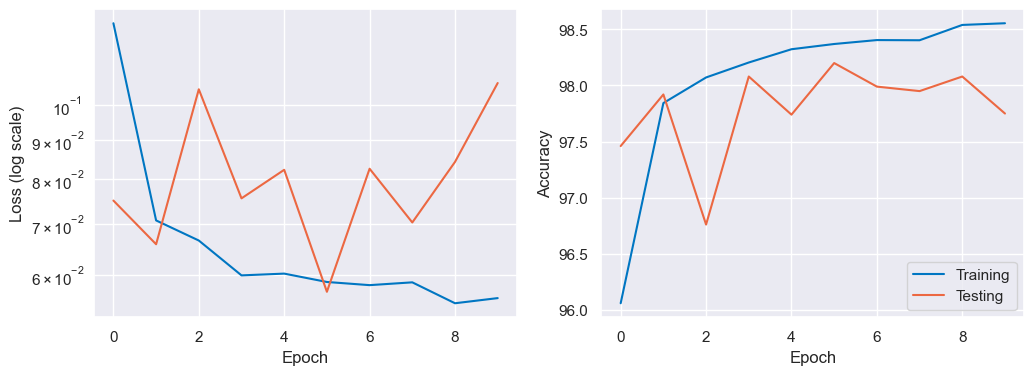

In [18]:
# Create a figure and axis object
fig, axs = plt.subplots(1, 2, figsize=(12,4))

# Plot the training loss and accuracy
axs[0].plot(CNN_history['train_losses'], 'C0-', label='Training')
axs[0].plot(CNN_history['test_losses'], 'C1-', label='Testing')

axs[1].plot(CNN_history['train_accuracies'], 'C0-', label='Training')
axs[1].plot(CNN_history['test_accuracies'], 'C1-', label='Testing')

# Add a legend to the plot
axs[1].legend(loc='lower right')

# Set the plot labels and title
axs[0].set_xlabel('Epoch')
axs[0].set_ylabel('Loss (log scale)')
axs[0].set_yscale('log')

axs[1].set_xlabel('Epoch')
axs[1].set_ylabel('Accuracy')

# Add grid lines to the plot
axs[0].grid(True, which='both')

# Display the plot
plt.show()

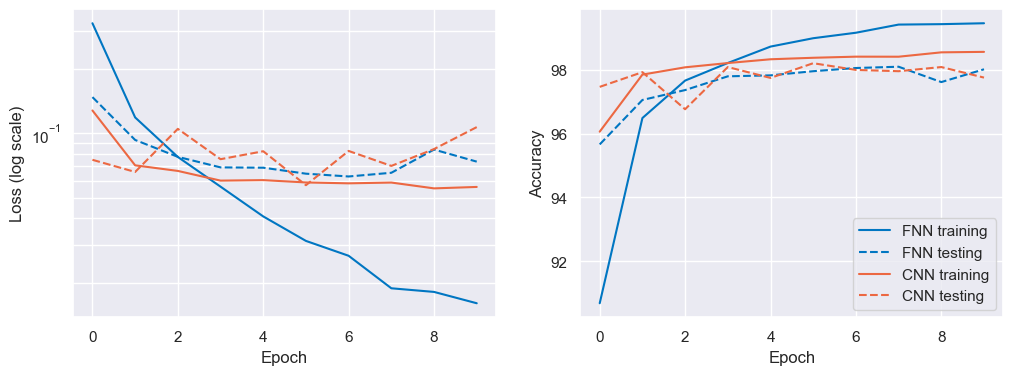

In [19]:
# Create a figure and axis object
fig, axs = plt.subplots(1, 2, figsize=(12,4))

# Plot the training loss and accuracy
axs[0].plot(FNN_history['train_losses'], 'C0-', label='FNN training')
axs[0].plot(FNN_history['test_losses'], 'C0--', label='FNN testing')
axs[0].plot(CNN_history['train_losses'], 'C1-', label='CNN training')
axs[0].plot(CNN_history['test_losses'], 'C1--', label='CNN testing')

axs[1].plot(FNN_history['train_accuracies'], 'C0-', label='FNN training')
axs[1].plot(FNN_history['test_accuracies'], 'C0--', label='FNN testing')
axs[1].plot(CNN_history['train_accuracies'], 'C1-', label='CNN training')
axs[1].plot(CNN_history['test_accuracies'], 'C1--', label='CNN testing')

# Add a legend to the plot
axs[1].legend(loc='lower right')

# Set the plot labels and title
axs[0].set_xlabel('Epoch')
axs[0].set_ylabel('Loss (log scale)')
axs[0].set_yscale('log')

axs[1].set_xlabel('Epoch')
axs[1].set_ylabel('Accuracy')

# Add grid lines to the plot
axs[0].grid(True, which='both')

# Display the plot
plt.show()

Despite having less parameters, the *CNN* works as good as the *FNN*. 
However, to really see the difference between the two architectures, we need to swtich to a more complex problem: *CIFAR10*.

# 2. CNN vs FNN on CIFAR10

We'll now load the CIFAR10 dataset, which consists of RGB images of several objects/animals.
You can see what labels the dataset has and what the images correspond to below.

In [20]:
transform = transforms.Compose(
    [transforms.ToTensor(),
     transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

root = '../../../../datasets/cifar10'

# load the CIFAR10 dataset
train_set = datasets.CIFAR10(root=root, download=True, train=True, transform=transform)
test_set = datasets.CIFAR10(root=root, download=True, train=False, transform=transform)

# get number of classes
num_classes = len(train_set.classes)
print(f'number of classes: {num_classes}')
print(f'The possible classes are: {train_set.classes}')

Files already downloaded and verified
Files already downloaded and verified
number of classes: 10
The possible classes are: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


Visualize random images to have a feeling of what it looks like. You can repeat running this cell as you wish to see further examples...

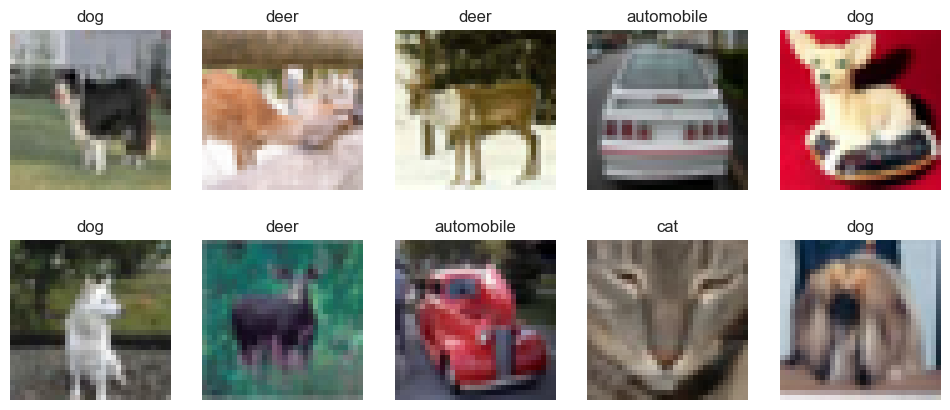

In [21]:
batch_size = 10
train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)

# get some random training images
dataiter = iter(train_loader)
images, labels = next(dataiter)

# show images
num_rows = 2
num_cols = 5
fig, axs = plt.subplots(num_rows, num_cols, figsize=(12,5))

for i in range(num_rows * num_cols):
    ax = axs[i // num_cols, i % num_cols]
    img = images[i] / 2 + 0.5     # unnormalize images
    ax.imshow(np.transpose(img, (1, 2, 0)), cmap='gray')
    ax.axis('off')
    ax.set_title(train_set.classes[labels[i]])

plt.show()

### FNN model (same procedure as before)

In [22]:
input_size = train_set.data[0].reshape(-1).shape[0] # flattended size of the image

# model
model = FNN(input_size, num_classes, hidden_features=256)
print("Total number of paramters:", sum(p.numel() for p in model.parameters()))

# Set training parameters
learning_rate = 0.001
batch_size = 64
num_epochs = 20

# Create the training and validation dataloaders to "feed" data to the model in batches
train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False)

# Create the optimizer to train the neural network via back-propagation
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate, momentum=0.9)

Total number of paramters: 855050


Despite the model being the same as before, you can see that the number of parameters has increased, since the images are now bigger than before and have 3 dimensions (for the RGB colors)

In [23]:
#create vector for saving training loss
FNN_history = {
    'train_losses' : [],
    'test_losses' : [],
    'train_accuracies' : [],
    'test_accuracies' : [],
}

for epoch in range(1, num_epochs+1):
    # Model training
    train_loss, train_accuracy = train_epoch(model, train_loader, optimizer, loss_function, device=device)
    test_loss, test_accuracy = evaluation(model, test_loader, loss_function, device=device)

    FNN_history['train_losses'].append(train_loss)
    FNN_history['train_accuracies'].append(train_accuracy)
    
    FNN_history['test_losses'].append(test_loss)
    FNN_history['test_accuracies'].append(test_accuracy)

    # print loss every epoch
    if epoch%1 == 0:
        print("epoch:",epoch, "\t training accuracy:", np.round(train_accuracy,2), 
                              "\t test accuracy:", np.round(test_accuracy,2))

epoch: 1 	 training accuracy: 27.87 	 test accuracy: 34.67
epoch: 2 	 training accuracy: 37.86 	 test accuracy: 40.2
epoch: 3 	 training accuracy: 41.96 	 test accuracy: 43.51
epoch: 4 	 training accuracy: 44.65 	 test accuracy: 45.96
epoch: 5 	 training accuracy: 46.88 	 test accuracy: 47.12
epoch: 6 	 training accuracy: 48.78 	 test accuracy: 48.64
epoch: 7 	 training accuracy: 50.33 	 test accuracy: 49.59
epoch: 8 	 training accuracy: 51.86 	 test accuracy: 51.11
epoch: 9 	 training accuracy: 53.5 	 test accuracy: 51.04
epoch: 10 	 training accuracy: 54.62 	 test accuracy: 51.94
epoch: 11 	 training accuracy: 55.75 	 test accuracy: 52.36
epoch: 12 	 training accuracy: 56.6 	 test accuracy: 52.32
epoch: 13 	 training accuracy: 57.8 	 test accuracy: 53.28
epoch: 14 	 training accuracy: 58.93 	 test accuracy: 52.98
epoch: 15 	 training accuracy: 59.79 	 test accuracy: 53.18
epoch: 16 	 training accuracy: 60.75 	 test accuracy: 53.55
epoch: 17 	 training accuracy: 61.72 	 test accuracy:

### CNN model (same procedure as before)

In [24]:
# The number of input channels is three because we are dealing with RGB images.
input_size = 3
num_pixels = 32

# model
model = CNN(num_pixels, input_size, num_classes, hidden_features=8)
print("Total number of paramters:", sum(p.numel() for p in model.parameters()))

# Set training parameters
learning_rate = 0.001
batch_size = 32
num_epochs = 20

# Create the training and validation dataloaders to "feed" data to the model in batches
train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False)

# Create the optimizer to train the neural network via back-propagation
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate, momentum=0.9)

Total number of paramters: 13690


Contrary to the FNN, the number of parameters has not increased much.
The only reason why it increased is because the images now have 3 dimensions (for the RGB colors).

In [25]:
#create vector for saving training loss
CNN_history = {
    'train_losses' : [],
    'test_losses' : [],
    'train_accuracies' : [],
    'test_accuracies' : [],
}

for epoch in range(1, num_epochs+1):
    # Model training
    train_loss, train_accuracy = train_epoch(model, train_loader, optimizer, loss_function, device=device)
    test_loss, test_accuracy = evaluation(model, test_loader, loss_function, device=device)

    CNN_history['train_losses'].append(train_loss)
    CNN_history['train_accuracies'].append(train_accuracy)
    
    CNN_history['test_losses'].append(test_loss)
    CNN_history['test_accuracies'].append(test_accuracy)

    # print loss every epoch
    if epoch%1 == 0:
        print("epoch:",epoch, "\t training accuracy:", np.round(train_accuracy,2), 
                              "\t test accuracy:", np.round(test_accuracy,2))

epoch: 1 	 training accuracy: 32.11 	 test accuracy: 42.76
epoch: 2 	 training accuracy: 46.98 	 test accuracy: 51.12
epoch: 3 	 training accuracy: 53.2 	 test accuracy: 55.46
epoch: 4 	 training accuracy: 56.46 	 test accuracy: 57.43
epoch: 5 	 training accuracy: 59.19 	 test accuracy: 59.55
epoch: 6 	 training accuracy: 60.89 	 test accuracy: 59.42
epoch: 7 	 training accuracy: 62.39 	 test accuracy: 62.18
epoch: 8 	 training accuracy: 63.73 	 test accuracy: 62.61
epoch: 9 	 training accuracy: 64.54 	 test accuracy: 62.58
epoch: 10 	 training accuracy: 65.26 	 test accuracy: 63.13
epoch: 11 	 training accuracy: 65.98 	 test accuracy: 63.25
epoch: 12 	 training accuracy: 66.61 	 test accuracy: 63.48
epoch: 13 	 training accuracy: 66.98 	 test accuracy: 63.32
epoch: 14 	 training accuracy: 67.29 	 test accuracy: 64.48
epoch: 15 	 training accuracy: 67.81 	 test accuracy: 63.81
epoch: 16 	 training accuracy: 68.24 	 test accuracy: 64.75
epoch: 17 	 training accuracy: 68.65 	 test accura

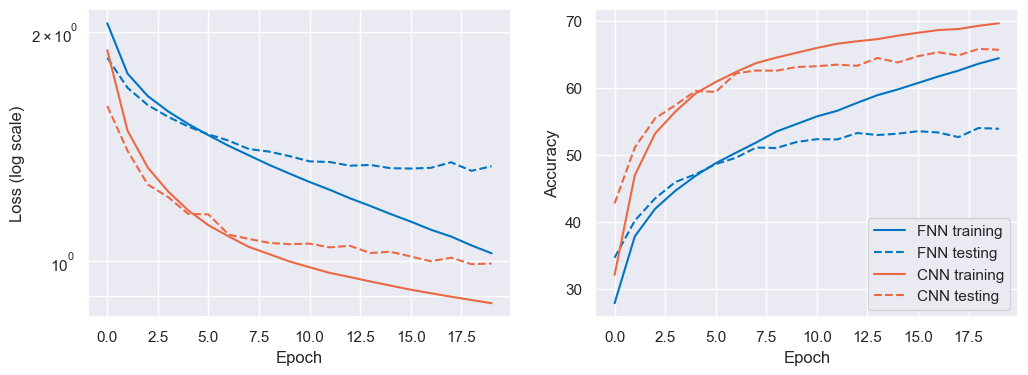

In [26]:
# Create a figure and axis object
fig, axs = plt.subplots(1, 2, figsize=(12,4))

# Plot the training loss and accuracy
axs[0].plot(FNN_history['train_losses'], 'C0-', label='FNN training')
axs[0].plot(FNN_history['test_losses'], 'C0--', label='FNN testing')
axs[0].plot(CNN_history['train_losses'], 'C1-', label='CNN training')
axs[0].plot(CNN_history['test_losses'], 'C1--', label='CNN testing')

axs[1].plot(FNN_history['train_accuracies'], 'C0-', label='FNN training')
axs[1].plot(FNN_history['test_accuracies'], 'C0--', label='FNN testing')
axs[1].plot(CNN_history['train_accuracies'], 'C1-', label='CNN training')
axs[1].plot(CNN_history['test_accuracies'], 'C1--', label='CNN testing')

# Add a legend to the plot
axs[1].legend(loc='lower right')

# Set the plot labels and title
axs[0].set_xlabel('Epoch')
axs[0].set_ylabel('Loss (log scale)')
axs[0].set_yscale('log')

axs[1].set_xlabel('Epoch')
axs[1].set_ylabel('Accuracy')

# Add grid lines to the plot
axs[0].grid(True, which='both')

# Display the plot
plt.show()

Despite the *FNN* having much more parameters, *CNN* performances are much superior. Due to *shared weights*, *translational invariance* and *hierarchical feature extraction*, the latter architecture is way more suitable for computer vision problems.

# 3. Improving generalization performances: going bigger

So far, we've used a very small model, just to show that it can work better than FNNs, but modern architectures generally use much bigger number of parameters.

Let's see what are the benefits of increasing the models's size: 
Now, we increase the number of hidden *filters* (feature maps) of the convolutional layers, as well as the number of hidden neurons in the *fully-connected* layer. We will compare the results with the ligher *CNN* model we trained before.

In [27]:
# The number of input channels is three because we are dealing with RGB images.
input_size = 3
num_pixels = 32

# model
model = CNN(num_pixels, input_size, num_classes, hidden_features=32)
print("Total number of paramters:", sum(p.numel() for p in model.parameters()))

# Set training parameters
learning_rate = 0.001
batch_size = 32
num_epochs = 20

# Create the training and validation dataloaders to "feed" data to the model in batches
train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False)

# Create the optimizer to train the neural network via back-propagation
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate, momentum=0.9)

Total number of paramters: 93130


In [28]:
#create vector for saving training loss
big_CNN_history = {
    'train_losses' : [],
    'test_losses' : [],
    'train_accuracies' : [],
    'test_accuracies' : [],
}

for epoch in range(1, num_epochs+1):
    # Model training
    train_loss, train_accuracy = train_epoch(model, train_loader, optimizer, loss_function, device=device)
    test_loss, test_accuracy = evaluation(model, test_loader, loss_function, device=device)

    big_CNN_history['train_losses'].append(train_loss)
    big_CNN_history['train_accuracies'].append(train_accuracy)
    
    big_CNN_history['test_losses'].append(test_loss)
    big_CNN_history['test_accuracies'].append(test_accuracy)

    # print loss every epoch
    if epoch%1 == 0:
        print("epoch:",epoch, "\t training accuracy:", np.round(train_accuracy,2), 
                              "\t test accuracy:", np.round(test_accuracy,2))

epoch: 1 	 training accuracy: 39.28 	 test accuracy: 51.17
epoch: 2 	 training accuracy: 53.98 	 test accuracy: 56.62
epoch: 3 	 training accuracy: 59.58 	 test accuracy: 61.52
epoch: 4 	 training accuracy: 63.19 	 test accuracy: 63.48
epoch: 5 	 training accuracy: 65.89 	 test accuracy: 65.63
epoch: 6 	 training accuracy: 68.39 	 test accuracy: 67.54
epoch: 7 	 training accuracy: 70.16 	 test accuracy: 67.83
epoch: 8 	 training accuracy: 71.46 	 test accuracy: 69.56
epoch: 9 	 training accuracy: 73.17 	 test accuracy: 70.05
epoch: 10 	 training accuracy: 74.21 	 test accuracy: 69.61
epoch: 11 	 training accuracy: 75.35 	 test accuracy: 71.43
epoch: 12 	 training accuracy: 76.58 	 test accuracy: 71.23
epoch: 13 	 training accuracy: 77.41 	 test accuracy: 71.56
epoch: 14 	 training accuracy: 78.32 	 test accuracy: 72.18
epoch: 15 	 training accuracy: 79.06 	 test accuracy: 72.43
epoch: 16 	 training accuracy: 79.78 	 test accuracy: 71.94
epoch: 17 	 training accuracy: 80.52 	 test accur

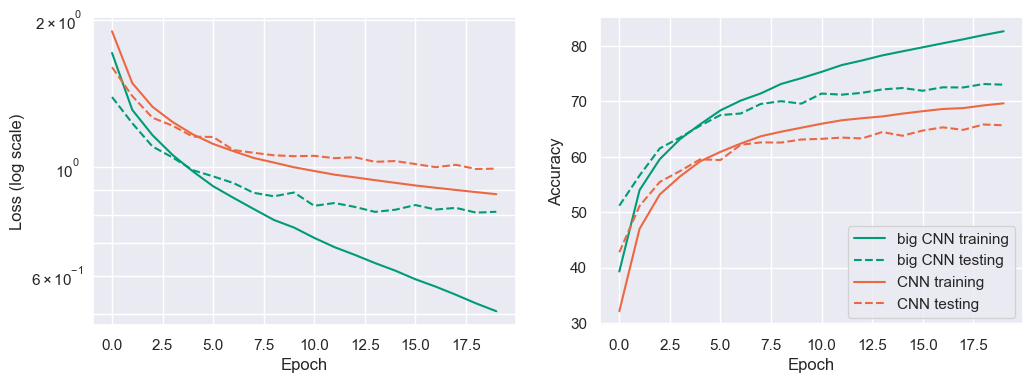

In [29]:
# Create a figure and axis object
fig, axs = plt.subplots(1, 2, figsize=(12,4))

# Plot the training loss and accuracy
axs[0].plot(big_CNN_history['train_losses'], 'C3-', label='big CNN training')
axs[0].plot(big_CNN_history['test_losses'], 'C3--', label='big CNN testing')
axs[0].plot(CNN_history['train_losses'], 'C1-', label='CNN training')
axs[0].plot(CNN_history['test_losses'], 'C1--', label='CNN testing')

axs[1].plot(big_CNN_history['train_accuracies'], 'C3-', label='big CNN training')
axs[1].plot(big_CNN_history['test_accuracies'], 'C3--', label='big CNN testing')
axs[1].plot(CNN_history['train_accuracies'], 'C1-', label='CNN training')
axs[1].plot(CNN_history['test_accuracies'], 'C1--', label='CNN testing')

# Add a legend to the plot
axs[1].legend(loc='lower right')

# Set the plot labels and title
axs[0].set_xlabel('Epoch')
axs[0].set_ylabel('Loss (log scale)')
axs[0].set_yscale('log')

axs[1].set_xlabel('Epoch')
axs[1].set_ylabel('Accuracy')

# Add grid lines to the plot
axs[0].grid(True, which='both')

# Display the plot
plt.show()

Now that the model is bigger, we have better training and testing loss and accuracy. However, if we keep increasing the size, we might end up *overfitting* the training dataset, a situation where a model learns the training data too well, capturing noise and random fluctuations rather than the underlying patterns, which can result in poor generalization to new, unseen data.

(check <a href="https://stats.stackexchange.com/questions/282160/how-is-it-possible-that-validation-loss-is-increasing-while-validation-accuracy#:~:text=After%20some%20time%2C%20validation%20loss,test%20accuracy%20continue%20to%20improve.&text=It%20seems%20that%20if%20validation%20loss%20increase%2C%20accuracy%20should%20decrease">here</a> for some answers on why validation accuracy does not decrease but remains stable despite an incraese in the validation loss).

In the following notebooks and lectures, we will explore different strategies and layers that can further improve the performance of our models.